In [13]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [14]:
data_dir = "../data/dataset"

files = sorted([
    f for f in os.listdir(data_dir) if f.endswith(".npy")
])

print(f"Found {len(files)} runs")
print("Example files:", files[:5])

Found 50 runs
Example files: ['run_000.npy', 'run_001.npy', 'run_002.npy', 'run_003.npy', 'run_004.npy']


In [15]:
file_path = os.path.join(data_dir, files[0])
traj = np.load(file_path)

print("Shape:", traj.shape)

Shape: (2000, 3, 2)


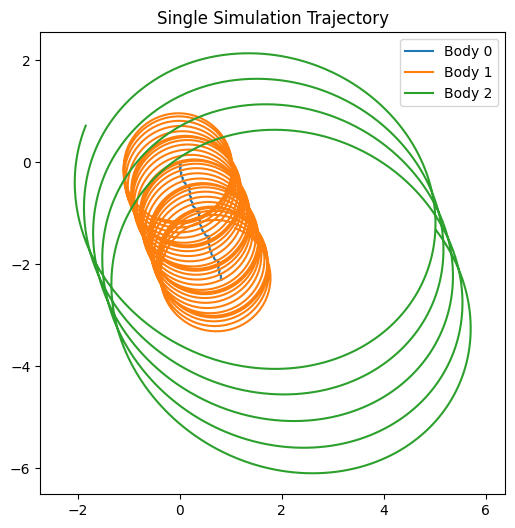

In [16]:
plt.figure(figsize=(6, 6))

for i in range(traj.shape[1]):
    plt.plot(traj[:, i, 0], traj[:, i, 1], label=f"Body {i}")

plt.title("Single Simulation Trajectory")
plt.axis("equal")
plt.legend()
plt.show()

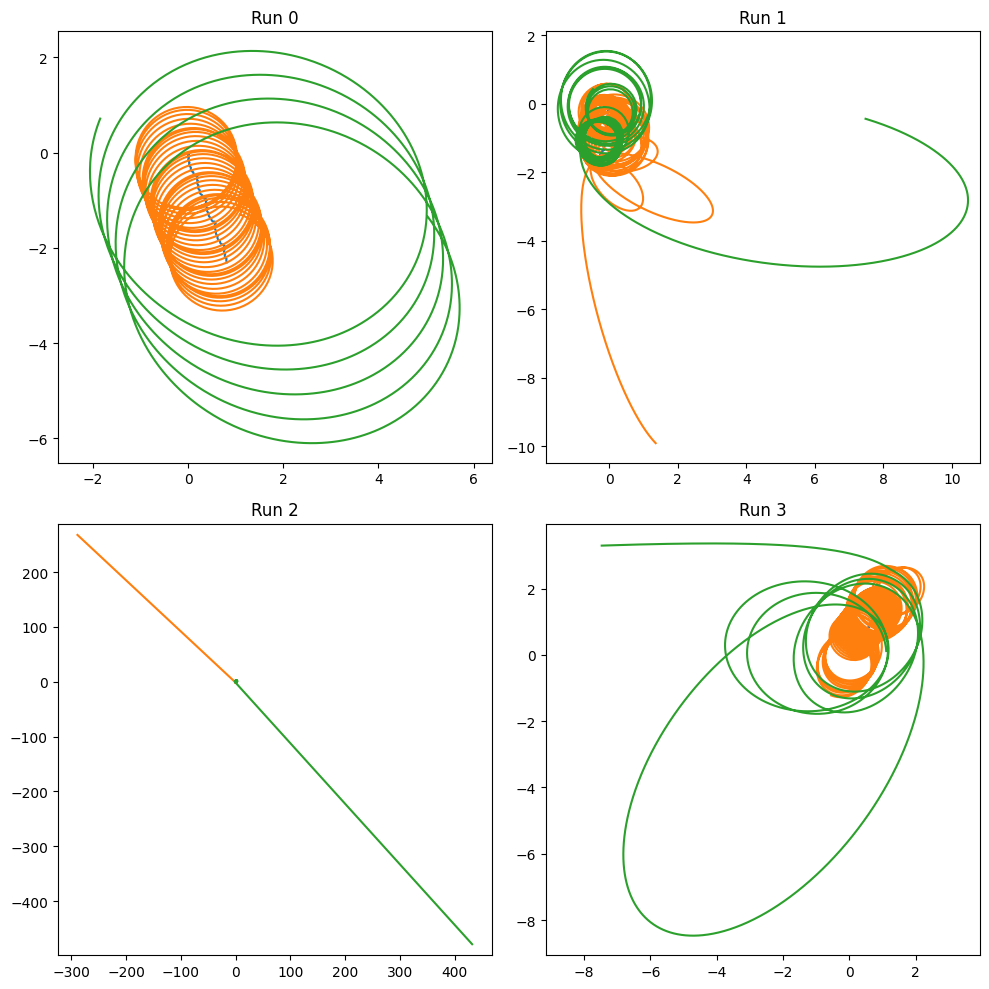

In [17]:
num_runs_to_plot = 4

plt.figure(figsize=(10, 10))

for idx in range(num_runs_to_plot):
    traj = np.load(os.path.join(data_dir, files[idx]))

    plt.subplot(2, 2, idx + 1)

    for i in range(traj.shape[1]):
        plt.plot(traj[:, i, 0], traj[:, i, 1])
    
    plt.title(f"Run {idx}")
    plt.axis("equal")

plt.tight_layout()
plt.show()

In [18]:
def max_distance(traj):
    dists = np.linalg.norm(traj, axis=2)
    return np.max(dists)

for i in range(5):
    traj = np.load(os.path.join(data_dir, files[i]))
    print(f"Run {i}: max distance = {max_distance(traj):.2f}")

Run 0: max distance = 7.15
Run 1: max distance = 10.89
Run 2: max distance = 644.33
Run 3: max distance = 10.05
Run 4: max distance = 3.72


In [19]:
def has_nan_or_inf(traj):
    return not np.isfinite(traj).all()

bad_runs = []

for i, f in enumerate(files):
    traj = np.load(os.path.join(data_dir, f))
    if has_nan_or_inf(traj):
        bad_runs.append(i)

print("Bad runs:", bad_runs)

Bad runs: []


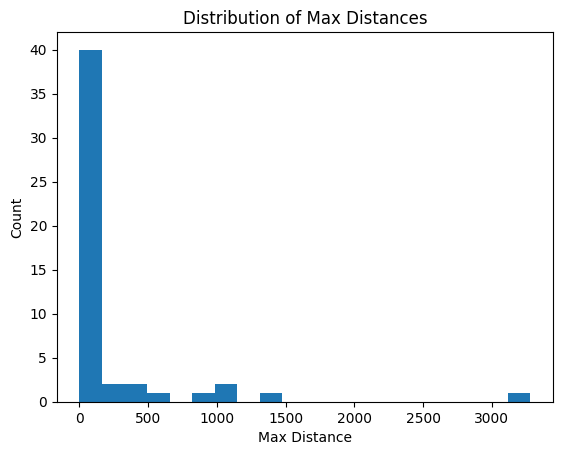

In [20]:
max_dists = []

for f in files:
    traj = np.load(os.path.join(data_dir, f))
    max_dists.append(max_distance(traj))

plt.hist(max_dists, bins=20)
plt.title("Distribution of Max Distances")
plt.xlabel("Max Distance")
plt.ylabel("Count")
plt.show()